In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

### Loading Data and Preprocessing


In [54]:
df = pd.read_csv('bank-full.csv', sep=';')

print(f'Dataset shape : {df.shape}')
print(f'Rows          : {df.shape[0]}')
print(f'Columns       : {df.shape[1]}')
df.head(10)

Dataset shape : (45211, 17)
Rows          : 45211
Columns       : 17


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [56]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'No missing values')

Missing values per column:
No missing values


#Class distribution and count

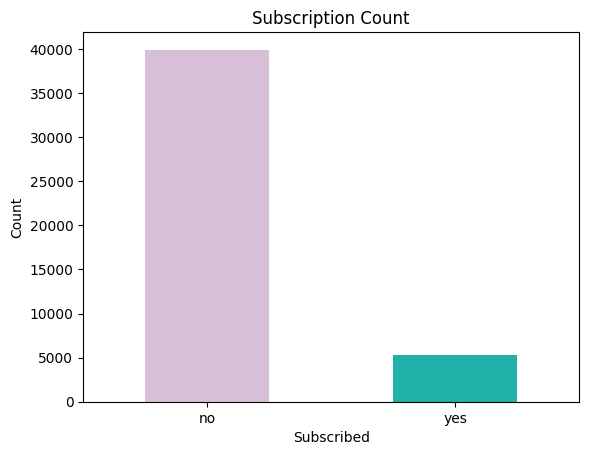

In [57]:
ax = df['y'].value_counts().plot(kind='bar', color=['thistle', 'lightseagreen'])
plt.title('Subscription Count')
plt.xticks(rotation=0)
plt.xlabel('Subscribed')
plt.ylabel('Count')
plt.show()

In [58]:
counts = df['y'].value_counts()
pct    = df['y'].value_counts(normalize=True) * 100
dist   = pd.DataFrame({'Count': counts, 'Percentage (%)': pct.round(2)})
dist.index.name = 'subscribed'
print('Class Distribution:')
print(dist)

Class Distribution:
            Count  Percentage (%)
subscribed                       
no          39922            88.3
yes          5289            11.7


In [59]:
for col in ['job', 'education', 'contact']:
    mode_value = df[col].mode()[0]
    df[col] = df[col].replace('unknown', mode_value)
    print(f"{col}: 'unknown' values filled with '{mode_value}'")

df.drop(columns=['duration', 'month', 'day', 'pdays', 'previous', 'poutcome'], inplace=True)
print("Dropped columns: 'duration', 'month', 'day', 'pdays', 'previous', 'poutcome'")

for col in ['default', 'housing', 'loan']:
    df[col] = df[col].map({'yes': 1, 'no': 0})

df['y'] = LabelEncoder().fit_transform(df['y'])

df = pd.get_dummies(df, columns=['job', 'marital', 'education', 'contact'], drop_first=True);

for col in df.select_dtypes(include='bool').columns:
    df[col] = df[col].astype(int)

print("\nShape after all preprocessing:", df.shape)
display(df.head())

job: 'unknown' values filled with 'blue-collar'
education: 'unknown' values filled with 'secondary'
contact: 'unknown' values filled with 'cellular'
Dropped columns: 'duration', 'month', 'day', 'pdays', 'previous', 'poutcome'

Shape after all preprocessing: (45211, 22)


,age,default,balance,housing,loan,campaign,y,job_blue-collar,job_entrepreneur,job_housemaid,...,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_married,marital_single,education_secondary,education_tertiary,contact_telephone
0,58,0,2143,1,0,1,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
1,44,0,29,1,0,1,0,0,0,0,...,0,0,0,1,0,0,1,1,0,0
2,33,0,2,1,1,1,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
3,47,0,1506,1,0,1,0,1,0,0,...,0,0,0,0,0,1,0,1,0,0
4,33,0,1,0,0,1,0,1,0,0,...,0,0,0,0,0,0,1,1,0,0


### Model training, Train / Test Split

In [60]:
X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)

sm = SMOTE(random_state=1)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_bal = scaler.fit_transform(X_train_bal)
X_test = scaler.transform(X_test)

In [61]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_bal, y_train_bal)

LogisticRegression(max_iter=1000)

In [62]:
y_pred = model.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print(classification_report(y_test, y_pred))

Accuracy : 0.7796
F1 Score : 0.2246
              precision    recall  f1-score   support

           0       0.90      0.85      0.87     11977
           1       0.19      0.27      0.22      1587

    accuracy                           0.78     13564
   macro avg       0.54      0.56      0.55     13564
weighted avg       0.82      0.78      0.80     13564



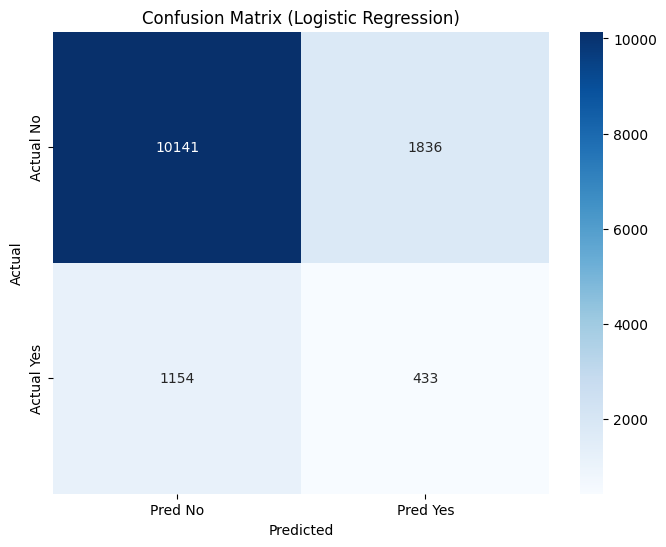

In [63]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred No', 'Pred Yes'],
            yticklabels=['Actual No', 'Actual Yes'])

plt.title('Confusion Matrix (Logistic Regression)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()